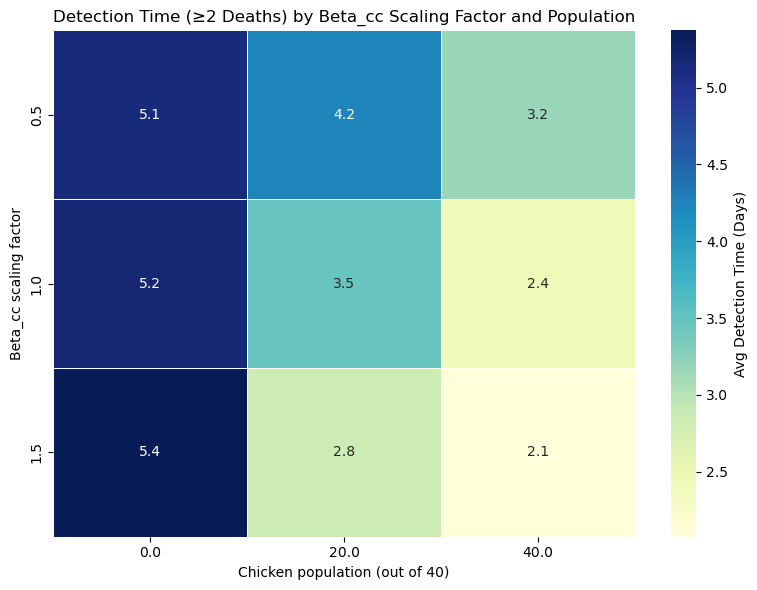

In [48]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import h5py
import numpy as np

threshold = 2
bch = [0.5, 1.0, 1.5]
chicken_levels = [0, 20, 40]
symprob = 0.2
rescale = 3.0
file_template = "chicken_{}_symprob_{}_rescale_{}_bch_{}_bduck_{}_totpop_40.h5"

# init dataframe
heatmap_data = pd.DataFrame(index=bch, columns=chicken_levels, dtype=float)

def compute_detection_time(output_file, threshold):
    try:
        with h5py.File(output_file, 'r') as f:
            detection_times = []
            for sim_name in f:
                if "state" in f[sim_name]:
                    state = f[sim_name]["state"][:]  # (T, x, y, C)
                    times = f[sim_name]["time"][:]
                    deaths = np.sum(state[:, :, :, 6], axis=(1, 2))
                    detected = np.where(deaths >= threshold)[0]
                    if detected.size > 0:
                        detection_times.append(times[detected[0]])
            return np.mean(detection_times) if detection_times else np.nan
    except FileNotFoundError:
        print(f"Missing file: {output_file}")
        return np.nan

for bch_num in bch:
    for chicken in chicken_levels:
        output_file = file_template.format(chicken, symprob, rescale, bch_num, 1.0)
        avg_detection_time = compute_detection_time(output_file, threshold)
        heatmap_data.loc[bch_num, chicken] = avg_detection_time

# make sure both index and columns are numeric
heatmap_data.columns = heatmap_data.columns.astype(float)
heatmap_data.index = heatmap_data.index.astype(float)

# plot
cmap = sns.color_palette("YlGnBu", as_cmap=True)
cmap.set_bad(color='#000000')

mask = heatmap_data.isna()

plt.figure(figsize=(8, 6))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    cmap=cmap,
    mask=mask,
    linewidths=0.5,
    cbar_kws={'label': 'Avg Detection Time (Days)'}
)

plt.title(f"Detection Time (≥{threshold} Deaths) by Beta_cc Scaling Factor and Population")
plt.ylabel("Beta_cc scaling factor")
plt.xlabel("Chicken population (out of 40)")
plt.tight_layout()
plt.show()


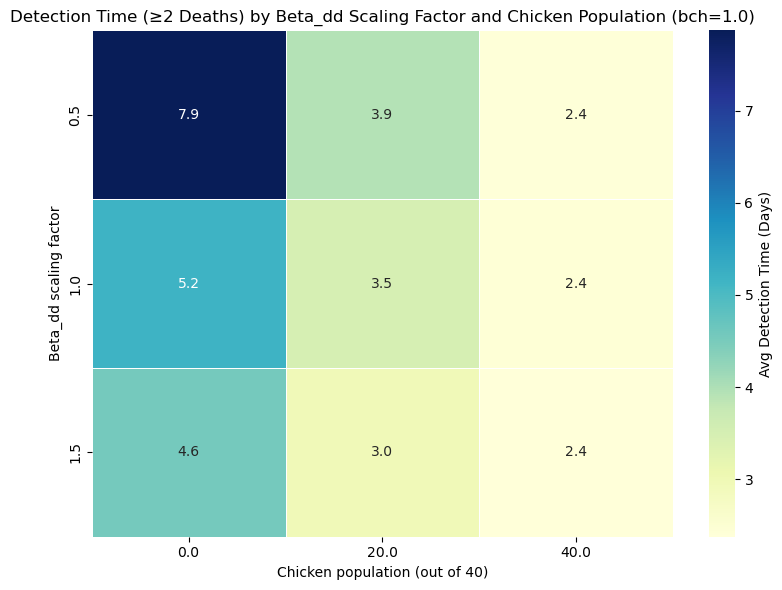

In [49]:


threshold = 2
bduck = [0.5, 1.0, 1.5]
chicken_levels = [0, 20, 40]
symprob = 0.2
rescale = 3.0
bch_fixed = 1.0
file_template = "chicken_{}_symprob_{}_rescale_{}_bch_{}_bduck_{}_totpop_40.h5"

# init dataframe
heatmap_data = pd.DataFrame(index=bduck, columns=chicken_levels, dtype=float)

# populate heatmap
for bduck_num in bduck:
    for chicken in chicken_levels:
        output_file = file_template.format(chicken, symprob, rescale, bch_fixed, bduck_num)
        avg_detection_time = compute_detection_time(output_file, threshold)
        heatmap_data.loc[bduck_num, chicken] = avg_detection_time

# make sure index/columns are numeric
heatmap_data.columns = heatmap_data.columns.astype(float)
heatmap_data.index = heatmap_data.index.astype(float)

# plot
cmap = sns.color_palette("YlGnBu", as_cmap=True)
cmap.set_bad(color='#000000')

mask = heatmap_data.isna()

plt.figure(figsize=(8, 6))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    cmap=cmap,
    mask=mask,
    linewidths=0.5,
    cbar_kws={'label': 'Avg Detection Time (Days)'}
)

plt.title(f"Detection Time (≥{threshold} Deaths) by Beta_dd Scaling Factor and Chicken Population (bch={bch_fixed})")
plt.ylabel("Beta_dd scaling factor")
plt.xlabel("Chicken population (out of 40)")
plt.tight_layout()
plt.show()


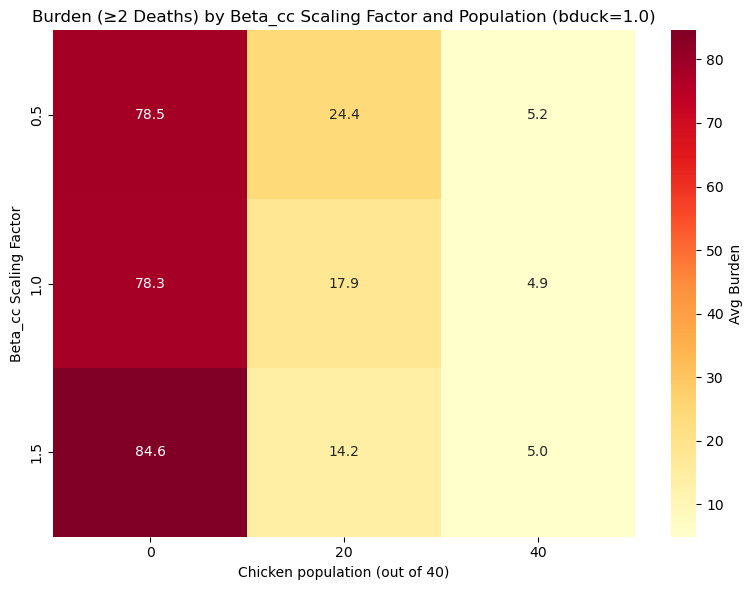

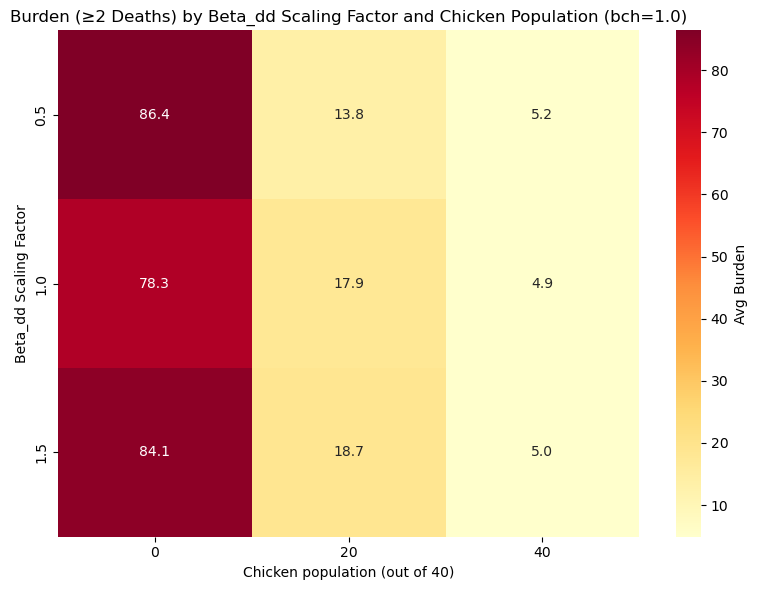

In [50]:

threshold = 2
chicken_factors = [0.5, 1.0, 1.5]
duck_factors = [0.5, 1.0, 1.5]
chicken_levels = [0, 20, 40]
symprob = 0.2
rescale = 3.0
file_template = "chicken_{}_symprob_{}_rescale_{}_bch_{}_bduck_{}_totpop_40.h5"

# --- burden function ---
def compute_burden(output_file, threshold):
    try:
        with h5py.File(output_file, 'r') as f:
            burdens = []
            for sim_name in f:
                if "state" in f[sim_name]:
                    y = f[sim_name]["state"][:]
                    t = f[sim_name]["time"][:]
                    cum_deaths = np.sum(y[:, :, :, 6], axis=(1, 2))
                    detect_idx = np.where(cum_deaths >= threshold)[0]
                    if detect_idx.size > 0:
                        stop = detect_idx[0] + 1
                        infectious = np.sum(y[:stop, :, :, 3:5], axis=(1, 2, 3))  # symptomatic + asymptomatic
                        burden = np.trapz(infectious, t[:stop])
                        burdens.append(burden)
            return np.mean(burdens) if burdens else np.nan
    except FileNotFoundError:
        print(f"Missing file: {output_file}")
        return np.nan


# --- Case 1: Vary chicken scale (fix duck) ---
bduck_fixed = 1.0
burden_chicken = pd.DataFrame(index=chicken_factors, columns=chicken_levels, dtype=float)

for bch_num in chicken_factors:
    for chicken in chicken_levels:
        output_file = file_template.format(chicken, symprob, rescale, bch_num, bduck_fixed)
        avg_burden = compute_burden(output_file, threshold)
        burden_chicken.loc[bch_num, chicken] = avg_burden

# plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    burden_chicken,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    cbar_kws={'label': 'Avg Burden'}
)
plt.title(f"Burden (≥{threshold} Deaths) by Beta_cc Scaling Factor and Population (bduck={bduck_fixed})")
plt.ylabel("Beta_cc Scaling Factor")
plt.xlabel("Chicken population (out of 40)")
plt.tight_layout()
plt.show()


# --- Case 2: Vary duck scale (fix chicken) ---
bch_fixed = 1.0
burden_duck = pd.DataFrame(index=duck_factors, columns=chicken_levels, dtype=float)

for bduck_num in duck_factors:
    for chicken in chicken_levels:
        output_file = file_template.format(chicken, symprob, rescale, bch_fixed, bduck_num)
        avg_burden = compute_burden(output_file, threshold)
        burden_duck.loc[bduck_num, chicken] = avg_burden

# plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    burden_duck,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    cbar_kws={'label': 'Avg Burden'}
)
plt.title(f"Burden (≥{threshold} Deaths) by Beta_dd Scaling Factor and Chicken Population (bch={bch_fixed})")
plt.ylabel("Beta_dd Scaling Factor")
plt.xlabel("Chicken population (out of 40)")
plt.tight_layout()
plt.show()


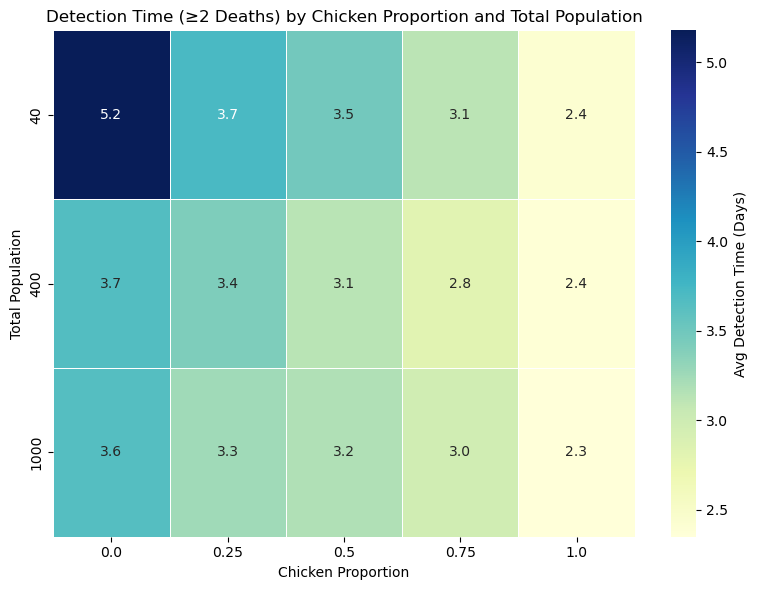

In [51]:

# --- Parameters ---
threshold = 2
total_population = [40, 400, 1000]
total_chicken_proportion = [0.0, 0.25, 0.5, 0.75, 1.0]
bch = 1.0
bduck = 1.0
symprob = 0.2
rescale = 3.0
file_template = "chicken_{}_symprob_{}_rescale_{}_bch_{}_bduck_{}_totpop_{}.h5"

# --- Populate heatmap data ---
heatmap_data = pd.DataFrame(
    index=total_population,
    columns=total_chicken_proportion,
    dtype=float
)

for t in total_population:
    for p in total_chicken_proportion:
        c = int(p * t)  # chicken count
        output_file = file_template.format(c, symprob, rescale, bch, bduck, t)
        avg_detection_time = compute_detection_time(output_file, threshold)
        heatmap_data.loc[t, p] = avg_detection_time

# --- Plot ---
plt.figure(figsize=(8, 6))
cmap = sns.color_palette("YlGnBu", as_cmap=True)
cmap.set_bad(color='#000000')  # Black for NaN
mask = heatmap_data.isna()

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    cmap=cmap,
    mask=mask,
    linewidths=0.5,
    cbar_kws={'label': 'Avg Detection Time (Days)'}
)

plt.title(f"Detection Time (≥{threshold} Deaths) by Chicken Proportion and Total Population")
plt.xlabel("Chicken Proportion")
plt.ylabel("Total Population")
plt.tight_layout()
plt.show()


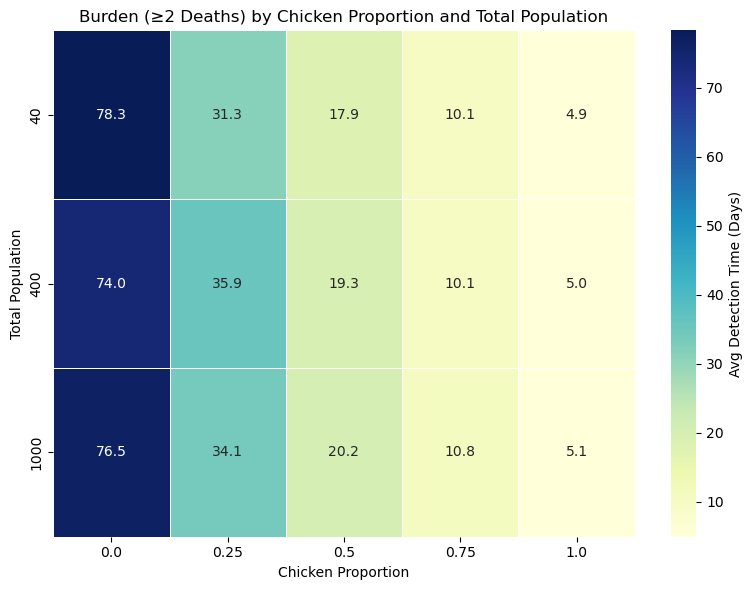

In [52]:

# --- Populate heatmap data ---
heatmap_data = pd.DataFrame(
    index=total_population,
    columns=total_chicken_proportion,
    dtype=float
)

for t in total_population:
    for p in total_chicken_proportion:
        c = int(p * t)  # chicken count
        output_file = file_template.format(c, symprob, rescale, bch, bduck, t)
        avg_detection_time =compute_burden(output_file, threshold)
        heatmap_data.loc[t, p] = avg_detection_time

# --- Plot ---
plt.figure(figsize=(8, 6))
cmap = sns.color_palette("YlGnBu", as_cmap=True)
cmap.set_bad(color='#000000')  # Black for NaN
mask = heatmap_data.isna()

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    cmap=cmap,
    mask=mask,
    linewidths=0.5,
    cbar_kws={'label': 'Avg Detection Time (Days)'}
)

plt.title(f"Burden (≥{threshold} Deaths) by Chicken Proportion and Total Population")
plt.xlabel("Chicken Proportion")
plt.ylabel("Total Population")
plt.tight_layout()
plt.show()
